In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [2]:
#=== Load the data ===#

train_df = pd.read_csv("WiDSWorldWide_GlobalDathon26/train.csv")
train_df = train_df.drop("event_id", axis=1)
test_df = pd.read_csv("WiDSWorldWide_GlobalDathon26/test.csv")
test_df = test_df.drop("event_id", axis=1)

meta_df = pd.read_csv("WiDSWorldWide_GlobalDathon26/metaData.csv")

submission = pd.read_csv("WiDSWorldWide_GlobalDathon26/sample_submission.csv")

In [3]:
train_df.head()


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [4]:
# Check dataset dimensions
print(f"Number of training samples: {train_df.shape[0]}")
print(f"Number of features: {train_df.shape[1]}")
print(f"Number of test samples: {test_df.shape[0]}")

Number of training samples: 221
Number of features: 36
Number of test samples: 95


In [8]:
# Calculate some basic statistics
n_hits = int(train_df['event'].sum())
n_censored = len(train_df) - n_hits
hit_times = train_df.loc[train_df['event'] == 1, 'time_to_hit_hours']

# Print a summary
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Training set:   {train_df.shape[0]} fires with {train_df.shape[1]} columns")
print(f"Test set:       {test_df.shape[0]} fires with {test_df.shape[1]} columns")
print()
print("Target distribution in training data:")
print(f"  Fires that HIT:        {n_hits} ({n_hits/len(train_df)*100:.1f}%)")
print(f"  Censored (no hit):     {n_censored} ({n_censored/len(train_df)*100:.1f}%)")
print()
print("Time to hit (for fires that hit):")
print(f"  Average: {hit_times.mean():.1f} hours")
print(f"  Median:  {hit_times.median():.1f} hours")
print(f"  Fastest: {hit_times.min():.2f} hours")
print(f"  Slowest: {hit_times.max():.1f} hours")
print()
print(f"Missing values: {train_df.isnull().sum().sum()}")
print("=" * 60)

DATASET SUMMARY
Training set:   221 fires with 36 columns
Test set:       95 fires with 34 columns

Target distribution in training data:
  Fires that HIT:        69 (31.2%)
  Censored (no hit):     152 (68.8%)

Time to hit (for fires that hit):
  Average: 10.0 hours
  Median:  3.5 hours
  Fastest: 0.00 hours
  Slowest: 66.9 hours

Missing values: 0


In [9]:
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_perimeters_0_5h           221 non-null    int64  
 1   dt_first_last_0_5h            221 non-null    float64
 2   low_temporal_resolution_0_5h  221 non-null    int64  
 3   area_first_ha                 221 non-null    float64
 4   area_growth_abs_0_5h          221 non-null    float64
 5   area_growth_rel_0_5h          221 non-null    float64
 6   area_growth_rate_ha_per_h     221 non-null    float64
 7   log1p_area_first              221 non-null    float64
 8   log1p_growth                  221 non-null    float64
 9   log_area_ratio_0_5h           221 non-null    float64
 10  relative_growth_0_5h          221 non-null    float64
 11  radial_growth_m               221 non-null    float64
 12  radial_growth_rate_m_per_h    221 non-null    float64
 13  centr

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,2.210000e+02,...,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,6.543391e-02,...,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,3.003211e-01,...,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,-1.437844e-07,...,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,0.000000e+00,...,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,2.938617e+00,...,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


quick reminder: 
Event Indicator (event) is binary variable where 1 indicates the fire reached within 5 km of an evacuation zone within 72 hours ("hit"), and 0 indicates censoring (did not reach within observation window).

In [14]:
# Fire-themed colors for charts
FIRE_COLORS = ['#ff6b35', '#ff3333', '#ffcc02', '#ff8c42']
HIT_COLOR = '#ff4444'      # Red for fires that hit
MISS_COLOR = '#58a6ff'     # Blue for fires that missed
SAFE_COLOR = '#3fb950'     # Green for safe zones

# Colors that work well on both dark and light backgrounds
BACKGROUND = '#0f1117'
CARD_BG = '#161b22'
TEXT_COLOR = '#e6edf3'
MUTED_COLOR = '#7d8590'
GRID_COLOR = '#21262d'


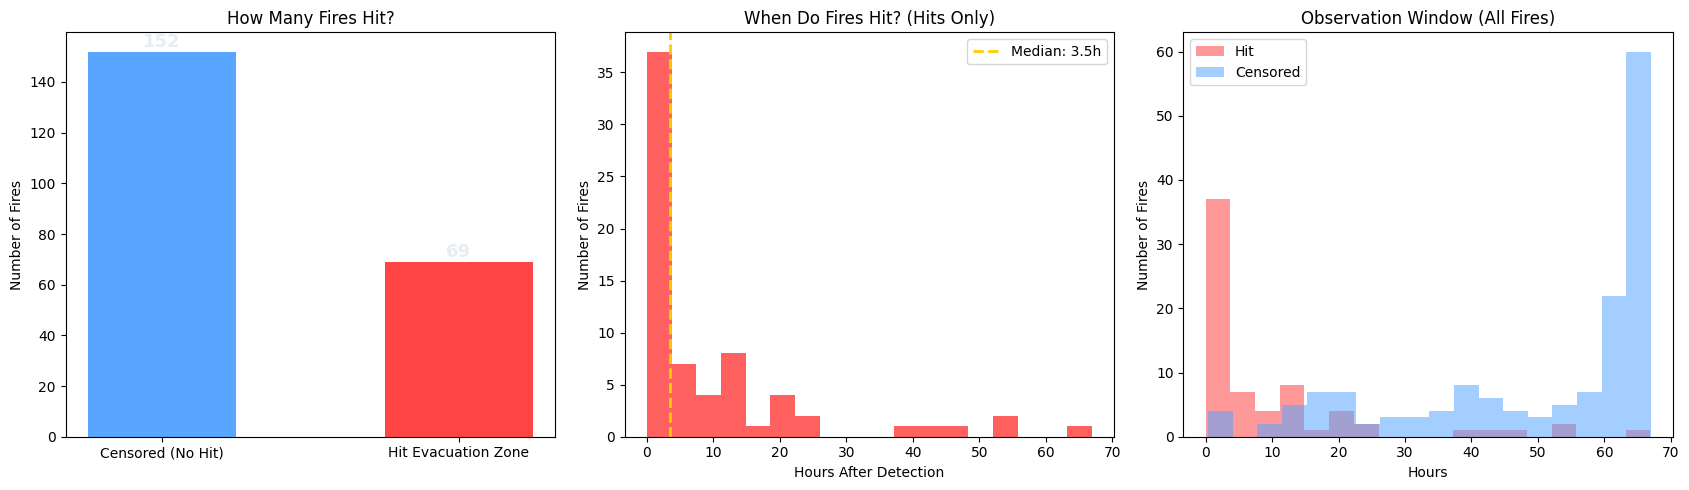

Key Insight: Most fires that hit do so within the first 20 hours!
  50% of hits occur within 3.5 hours
  75% of hits occur within 14.3 hours


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Chart 1: Event distribution (hit vs censored)
counts = train_df['event'].value_counts().sort_index()
bars = axes[0].bar(
    ['Censored (No Hit)', 'Hit Evacuation Zone'],
    counts.values,
    color=[MISS_COLOR, HIT_COLOR],
    edgecolor='none',
    width=0.5
)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        count + 2,
        str(count),
        ha='center',
        color=TEXT_COLOR,
        fontweight='bold',
        fontsize=13
    )

axes[0].set_title('How Many Fires Hit?')
axes[0].set_ylabel('Number of Fires')

# Chart 2: Time to hit distribution (hits only)
hits = train_df[train_df['event'] == 1]['time_to_hit_hours']
axes[1].hist(hits, bins=18, color=HIT_COLOR, alpha=0.85, edgecolor='none')
axes[1].axvline(
    hits.median(),
    color=FIRE_COLORS[2],
    ls='--',
    lw=2,
    label=f'Median: {hits.median():.1f}h'
)
axes[1].set_title('When Do Fires Hit? (Hits Only)')
axes[1].set_xlabel('Hours After Detection')
axes[1].set_ylabel('Number of Fires')
axes[1].legend()


# Chart 3: Observation window for all fires
for label, color, mask in [
    ('Hit', HIT_COLOR, train_df['event'] == 1),
    ('Censored', MISS_COLOR, train_df['event'] == 0)
]:
    axes[2].hist(
        train_df.loc[mask, 'time_to_hit_hours'],
        bins=18,
        alpha=0.55,
        color=color,
        label=label,
        edgecolor='none'
    )

axes[2].set_title('Observation Window (All Fires)')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Number of Fires')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Key Insight: Most fires that hit do so within the first 20 hours!")
print(f"  50% of hits occur within {hits.median():.1f} hours")
print(f"  75% of hits occur within {hits.quantile(0.75):.1f} hours")

In [ ]:
#== check distance

print("Total rows:", len(train_df))
print("Total hits:", train_df["event"].sum())
print("Hit rate:", train_df["event"].mean())

print("\nHits by horizon:")
for H in [12, 24, 48, 72]:
    hits = ((train_df["event"] == 1) & 
            (train_df["time_to_hit_hours"] <= H)).sum()

    print(f"Hit by {H}h:", hits)

Total rows: 221
Total hits: 69
Hit rate: 0.31221719457013575

Hits by horizon:
Hit by 12h: 49
Hit by 24h: 63
Hit by 48h: 66
Hit by 72h: 69



**Observations:**

- Most of the fires that hit, hit early:
- 49/69 hit by 12h → ~71% of the hits happen early.
- Only 6 more fires hit after 48h (69 total hits vs 66 by 48h).

**Implication for modeling horizons:**

- 12h: 49 positives → small but doable.
- 24h: 63 positives → slightly better.
- 48h: 66 positives → strongest signal (also weighted highest in competition metric).
- 72h: 69 positives → barely more than 48h.

So biggest learning opportunity is at 48h.

**Takeaway About the Dataset**

- This is right-censored survival data: the fires that didn’t hit by 72h are censored.
- Most hits happen early. Only a handful hit late.
- That means model needs to capture early dynamics: growth, distance, speed, alignment.

In [35]:
#==check seperation

train_df.groupby("event")[[
    "dist_min_ci_0_5h",
    "closing_speed_m_per_h",
    "area_growth_rate_ha_per_h"
]].mean()

,dist_min_ci_0_5h,closing_speed_m_per_h,area_growth_rate_ha_per_h
event,,,
0,179832.30310,0.081931,1.476825
1,2285.81835,6.293863,16.499391


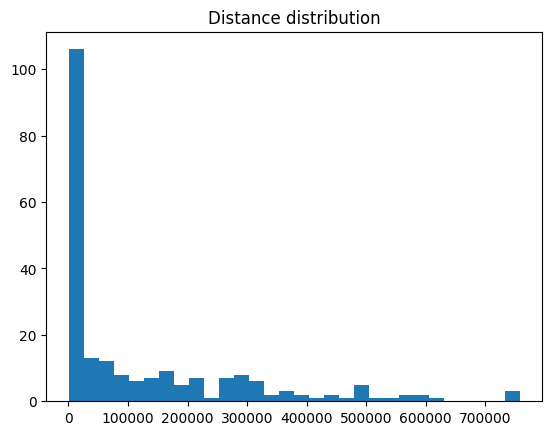

In [36]:
plt.hist(train_df["dist_min_ci_0_5h"], bins=30)
plt.title("Distance distribution")
plt.show()

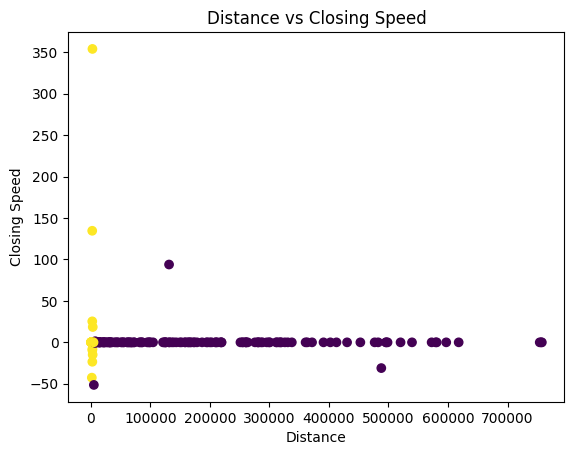

In [37]:
plt.scatter(train_df["dist_min_ci_0_5h"],
            train_df["closing_speed_m_per_h"],
            c=train_df["event"])
plt.xlabel("Distance")
plt.ylabel("Closing Speed")
plt.title("Distance vs Closing Speed")
plt.show()